# ITSM-ATR Strategy — Backtest + CSCV

**Research basis:** Intraday Time-Series Momentum in equity index futures (Notre Dame / Birmingham / AQR)  
Combined with ATR-scaled risk management to eliminate the primary CSCV overfitting driver.

**Signal:** `r_open = log(close[itsm_bars-1] / open[0])` — enter in direction of first 25-min return  
**SL:** `sl_atr_mult × ATR` (regime-adaptive — scales with volatility)  
**TP:** `tp_atr_mult × ATR` (2:1 RR default — regime-adaptive)  
**Backstop exit:** 15:30 time-based if neither SL nor TP fires  

**CSCV design rationale:**
- Fixed SL/TP in ORB caused 70-84pp PBO spread (primary driver)
- ATR-scaled stops adapt to volatility regime → same proportional risk always
- Expected PBO: LOW (regime-agnostic by construction)

**Baseline (from parameter sweep):** SL=0.5×ATR, TP=1.0×ATR, threshold=0.2%, bars=5  
- Sharpe: ~1.15 | Max DD: ~9.5% | Return: ~101%

In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re

THIS_DIR     = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(THIS_DIR, '..', '..'))
NOTEBOOK_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'ORB_ITSM')
for p in [PROJECT_ROOT, NOTEBOOK_DIR]:
    if p not in sys.path: sys.path.insert(0, p)

from data_fetch import fetch_data
from strategy_itsm_atr import run_backtest, INITIAL_EQUITY
from cscv_itsm_atr import build_pnl_matrix, run_cscv, sharpe_cols, pbo_verdict

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

SP500_SHARPE = 0.6
SP500_MAXDD  = 55.0
SP500_RETURN = 170.0

def get_float(s):
    m = re.search(r'[-\d.]+', str(s))
    return float(m.group()) if m else float('nan')

def compute_metrics(trades, equity):
    if trades.empty: return {}
    total = len(trades)
    wins  = (trades['pnl'] > 0).sum()
    wr    = wins / total * 100
    tpy   = (total / trades['date'].nunique()) * 252
    mean_p = trades['pnl'].mean()
    std_p  = trades['pnl'].std(ddof=1)
    sharpe = (mean_p / std_p) * math.sqrt(tpy) if std_p else float('nan')
    peak   = equity.cummax()
    mdd    = abs(((equity - peak) / peak * 100).min())
    net    = trades['pnl'].sum()
    ret    = (equity.iloc[-1] - INITIAL_EQUITY) / INITIAL_EQUITY * 100
    gw     = trades.loc[trades['pnl'] > 0, 'pnl'].sum()
    gl     = abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum())
    pf     = gw / gl if gl > 0 else float('inf')
    exits  = trades['exit_reason'].value_counts()
    return {
        'Trades': total, 'Win Rate': f'{wr:.1f}%',
        'Sharpe': f'{sharpe:.3f}', 'Max Drawdown': f'{mdd:.1f}%',
        'Net P&L': f'${net:,.0f}', 'Total Return': f'{ret:.1f}%',
        'Profit Factor': f'{pf:.2f}',
        'SL exits': f'{exits.get("SL",0)/total*100:.0f}%',
        'TP exits': f'{exits.get("TP",0)/total*100:.0f}%',
        'TIME exits': f'{exits.get("TIME",0)/total*100:.0f}%',
    }

print('Setup complete.')

Setup complete.


In [3]:
df = fetch_data(refresh=False)
print(f'Bars loaded : {len(df):,}')
print(f'Date range  : {df.index[0].date()} to {df.index[-1].date()}')

[data_fetch] Loading cached data from C:\Users\kunpa\Downloads\Projects\Futures_v2\data\NQ_5m.csv ...


[data_fetch] Loaded 222,295 rows (2014-12-19 -> 2026-03-17)
Bars loaded : 222,295
Date range  : 2014-12-19 to 2026-03-17


---
## Section 1 — Backtest: Key Variants

In [4]:
# Baseline (best from sweep): SL=0.5xATR, TP=1.0xATR, threshold=0.002, bars=5
t_base, eq_base = run_backtest(df, sl_atr_mult=0.5, tp_atr_mult=1.0,
                                itsm_threshold=0.002, itsm_bars=5)

# V2: wider SL (0.75x)
t_v2, eq_v2 = run_backtest(df, sl_atr_mult=0.75, tp_atr_mult=1.5,
                             itsm_threshold=0.002, itsm_bars=5)

# V3: even tighter threshold (0.003)
t_v3, eq_v3 = run_backtest(df, sl_atr_mult=0.5, tp_atr_mult=1.0,
                             itsm_threshold=0.003, itsm_bars=5)

# V4: 4-bar window (20-min signal)
t_v4, eq_v4 = run_backtest(df, sl_atr_mult=0.75, tp_atr_mult=1.5,
                             itsm_threshold=0.002, itsm_bars=4)

m_base = compute_metrics(t_base, eq_base)
m_v2   = compute_metrics(t_v2,   eq_v2)
m_v3   = compute_metrics(t_v3,   eq_v3)
m_v4   = compute_metrics(t_v4,   eq_v4)

sp500_row = {
    'Trades':'-','Win Rate':'-','Sharpe':str(SP500_SHARPE),
    'Max Drawdown':f'{SP500_MAXDD}%','Net P&L':'-','Total Return':f'{SP500_RETURN}%',
    'Profit Factor':'-','SL exits':'-','TP exits':'-','TIME exits':'-',
}

summary = pd.DataFrame({
    'Baseline (SL=0.5,thr=0.002,b=5)': m_base,
    'V2 (SL=0.75,thr=0.002,b=5)':       m_v2,
    'V3 (SL=0.5,thr=0.003,b=5)':        m_v3,
    'V4 (SL=0.75,thr=0.002,b=4)':       m_v4,
    'S&P 500':                            sp500_row,
}).T
print(summary.to_string())

                                Trades Win Rate Sharpe Max Drawdown  Net P&L Total Return Profit Factor SL exits TP exits TIME exits
Baseline (SL=0.5,thr=0.002,b=5)   1584    48.7%  1.151         9.5%  $50,304       100.6%          1.19      34%      10%        54%
V2 (SL=0.75,thr=0.002,b=5)        1584    52.2%  0.888         9.5%  $30,557        61.1%          1.15      20%       3%        76%
V3 (SL=0.5,thr=0.003,b=5)         1129    49.6%  1.362        12.8%  $42,719        85.4%          1.23      35%      11%        54%
V4 (SL=0.75,thr=0.002,b=4)        1481    52.4%  1.029         8.8%  $34,111        68.2%          1.18      20%       3%        75%
S&P 500                              -        -    0.6        55.0%        -       170.0%             -        -        -          -


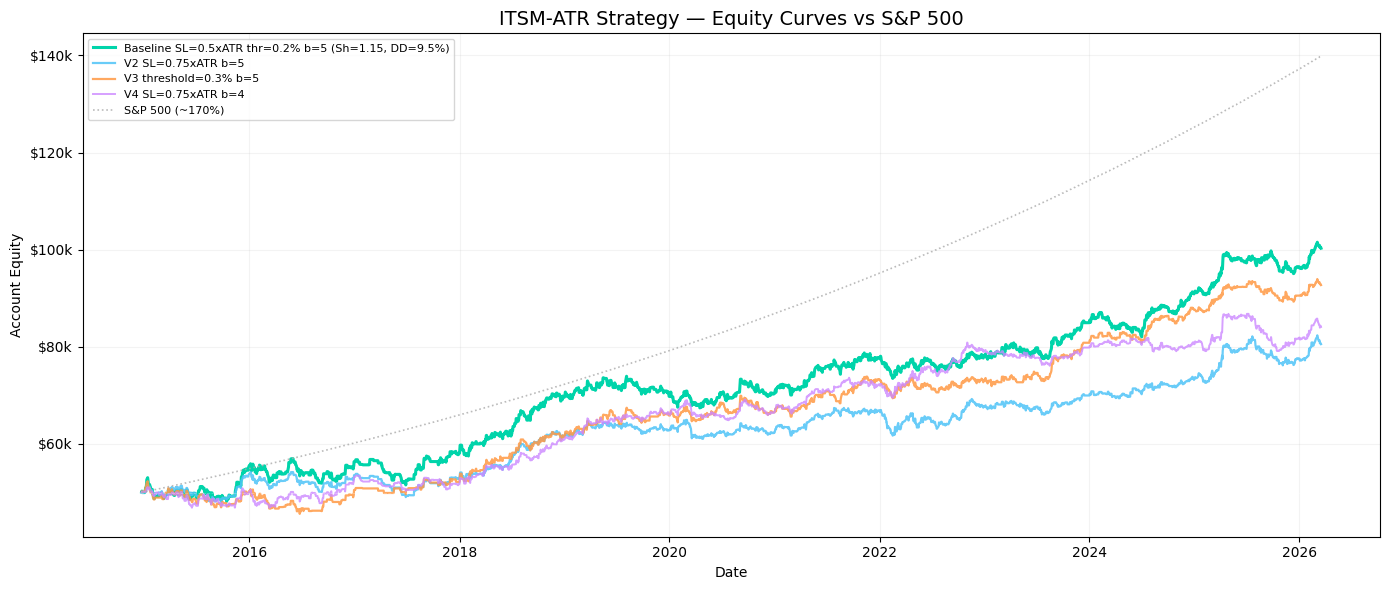

In [5]:
# Equity curves
start = eq_base.index[0]
end   = eq_base.index[-1]
years = (end - start).days / 365.25
cagr  = (1 + SP500_RETURN/100)**(1/years) - 1 if years > 0 else 0
bdays = pd.bdate_range(start, end)
dr    = (1 + cagr)**(1/252) - 1
sp500_eq = pd.Series(INITIAL_EQUITY*(1+dr)**np.arange(len(bdays)), index=bdays)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eq_base.index, eq_base.values, color='#00d4aa', lw=2.2,
        label=f'Baseline SL=0.5xATR thr=0.2% b=5 (Sh={get_float(m_base["Sharpe"]):.2f}, DD={get_float(m_base["Max Drawdown"]):.1f}%)')
ax.plot(eq_v2.index,   eq_v2.values,   color='#4fc3f7', lw=1.6,
        label=f'V2 SL=0.75xATR b=5', alpha=0.85)
ax.plot(eq_v3.index,   eq_v3.values,   color='#ff9944', lw=1.6,
        label=f'V3 threshold=0.3% b=5', alpha=0.85)
ax.plot(eq_v4.index,   eq_v4.values,   color='#cc88ff', lw=1.4,
        label=f'V4 SL=0.75xATR b=4', alpha=0.8)
ax.plot(sp500_eq.index, sp500_eq.values, color='#aaaaaa', lw=1.2,
        linestyle=':', label=f'S&P 500 (~{SP500_RETURN:.0f}%)', alpha=0.8)
ax.axhline(INITIAL_EQUITY, color='white', lw=0.6, linestyle='--', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.set_title('ITSM-ATR Strategy — Equity Curves vs S&P 500', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Account Equity')
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.15)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'itsm_atr_equity.png'), dpi=150)
plt.show()

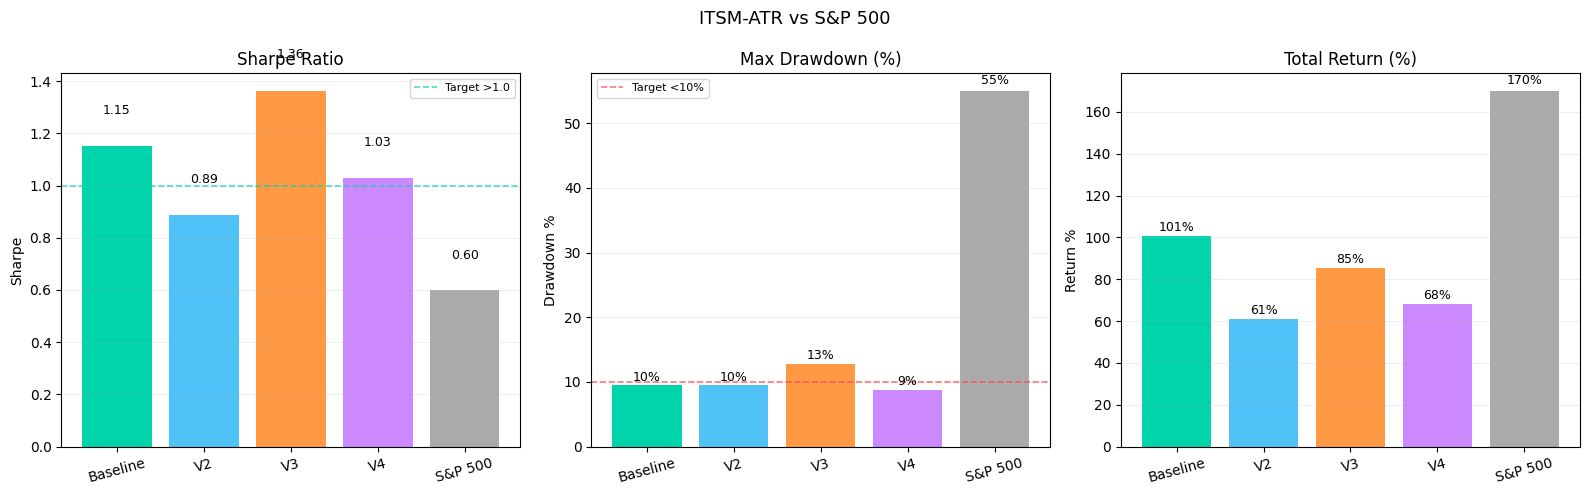

In [6]:
# Metrics bar charts
var_labels  = ['Baseline', 'V2', 'V3', 'V4', 'S&P 500']
var_metrics = [m_base, m_v2, m_v3, m_v4, sp500_row]
var_colors  = ['#00d4aa', '#4fc3f7', '#ff9944', '#cc88ff', '#aaaaaa']
sharpes = [get_float(m.get('Sharpe',0))      for m in var_metrics]
maxdds  = [get_float(m.get('Max Drawdown',0)) for m in var_metrics]
returns = [get_float(m.get('Total Return',0)) for m in var_metrics]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, vals, title, ylabel in [
    (axes[0], sharpes, 'Sharpe Ratio',     'Sharpe'),
    (axes[1], maxdds,  'Max Drawdown (%)', 'Drawdown %'),
    (axes[2], returns, 'Total Return (%)', 'Return %'),
]:
    bars = ax.bar(var_labels, vals, color=var_colors)
    if title == 'Sharpe Ratio':
        ax.axhline(1.0, color='#00d4aa', lw=1.2, linestyle='--', alpha=0.7, label='Target >1.0')
        ax.legend(fontsize=8)
    if title == 'Max Drawdown (%)':
        ax.axhline(10.0, color='#ff4444', lw=1.2, linestyle='--', alpha=0.7, label='Target <10%')
        ax.legend(fontsize=8)
    for b, v in zip(bars, vals):
        if v == v:
            ax.text(b.get_x()+b.get_width()/2, v+abs(v)*0.01+0.1,
                    f'{v:.2f}' if title=='Sharpe Ratio' else f'{v:.0f}%',
                    ha='center', va='bottom', fontsize=9)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15); ax.grid(axis='y', alpha=0.2)
fig.suptitle('ITSM-ATR vs S&P 500', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'itsm_atr_metrics.png'), dpi=150)
plt.show()

---
## Section 2 — CSCV: Build P&L Matrix

**36-variant grid:** `sl_atr_mult` [0.5, 0.75, 1.0, 1.25] × `RR` [1.5, 2.0, 2.5] × `threshold` [0.001, 0.002, 0.003]  
`itsm_bars=5` fixed (baseline window).  

**Hypothesis:** ATR-scaled stops should have near-zero PBO spread across sl_atr_mult values
because each value adapts proportionally to volatility — no regime-specific overfitting.

In [7]:
SL_MULTS   = [0.5, 0.75, 1.0, 1.25]
RR_RATIOS  = [1.5, 2.0, 2.5]          # TP = SL * RR
THRESHOLDS = [0.001, 0.002, 0.003]
ITSM_BARS  = 5                         # fixed

variants = [
    {
        'sl_atr_mult':    sl,
        'tp_atr_mult':    round(sl * rr, 4),
        'itsm_threshold': thr,
        'itsm_bars':      ITSM_BARS,
    }
    for sl  in SL_MULTS
    for rr  in RR_RATIOS
    for thr in THRESHOLDS
]

N = len(variants)
print(f'N = {N} variants')
print('Sample:')
for v in variants[:3]:
    print(f'  SL={v["sl_atr_mult"]}xATR  TP={v["tp_atr_mult"]}xATR  thr={v["itsm_threshold"]}')

N = 36 variants
Sample:
  SL=0.5xATR  TP=0.75xATR  thr=0.001
  SL=0.5xATR  TP=0.75xATR  thr=0.002
  SL=0.5xATR  TP=0.75xATR  thr=0.003


In [8]:
print('Building P&L matrix...')
M, dates = build_pnl_matrix(df, variants)
T = M.shape[0]
print(f'Shape: {M.shape}  (T={T} days, N={N} variants)')
print(f'Range: {dates[0].date()} to {dates[-1].date()}')

Building P&L matrix...


  10/36 variants complete...


  20/36 variants complete...


  30/36 variants complete...


Shape: (2164, 36)  (T=2164 days, N=36 variants)
Range: 2014-12-19 to 2026-03-17


---
## Section 3 — Run CSCV

In [9]:
S = 16
print(f'Running CSCV  S={S}  C(16,8)=12,870 combinations...')
results = run_cscv(M, S=S)

pbo               = results['pbo']
logits            = results['logits']
is_sharpes        = results['is_sharpes']
oos_sharpes       = results['oos_sharpes']
selected_variants = results['selected_variants']
prob_loss         = float(np.mean(oos_sharpes < 0))
full_sharpes      = sharpe_cols(M)

print(f'\nPBO  = {pbo*100:.1f}%  {pbo_verdict(pbo)}')
print(f'Median IS Sharpe  : {np.median(is_sharpes):.3f}')
print(f'Median OOS Sharpe : {np.median(oos_sharpes):.3f}')
print(f'Prob(loss OOS)    : {prob_loss*100:.1f}%')

Running CSCV  S=16  C(16,8)=12,870 combinations...



PBO  = 60.6%  HIGH OVERFITTING RISK (PBO >= 50%)
Median IS Sharpe  : 1.220
Median OOS Sharpe : 0.703
Prob(loss OOS)    : 2.1%


## Chart 1 — Logit Distribution

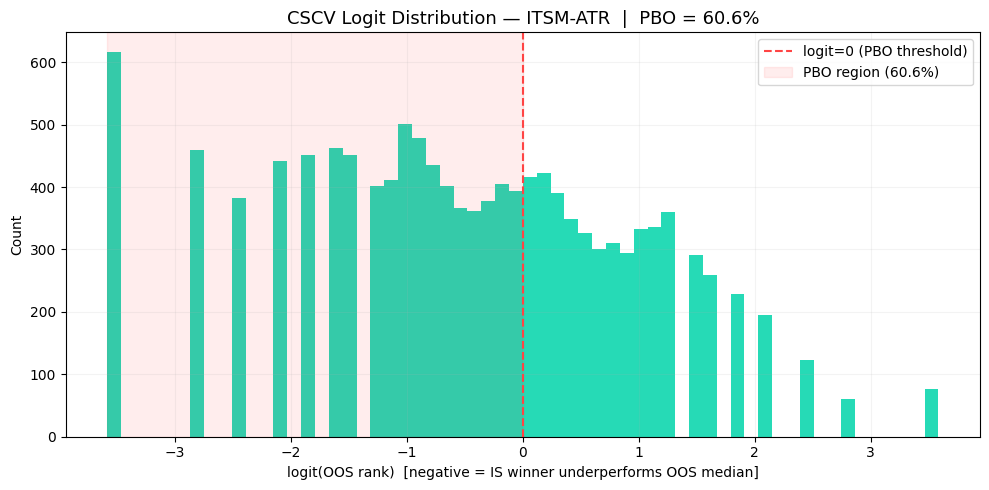

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(logits, bins=60, color='#00d4aa', edgecolor='none', alpha=0.85)
ax.axvline(0, color='#ff4444', lw=1.5, linestyle='--', label='logit=0 (PBO threshold)')
neg_frac = np.mean(logits < 0)
ax.axvspan(logits.min(), 0, alpha=0.07, color='red', label=f'PBO region ({neg_frac*100:.1f}%)')
ax.set_title(f'CSCV Logit Distribution — ITSM-ATR  |  PBO = {pbo*100:.1f}%', fontsize=13)
ax.set_xlabel('logit(OOS rank)  [negative = IS winner underperforms OOS median]')
ax.set_ylabel('Count')
ax.legend(); ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

## Chart 2 — IS vs OOS Sharpe Scatter

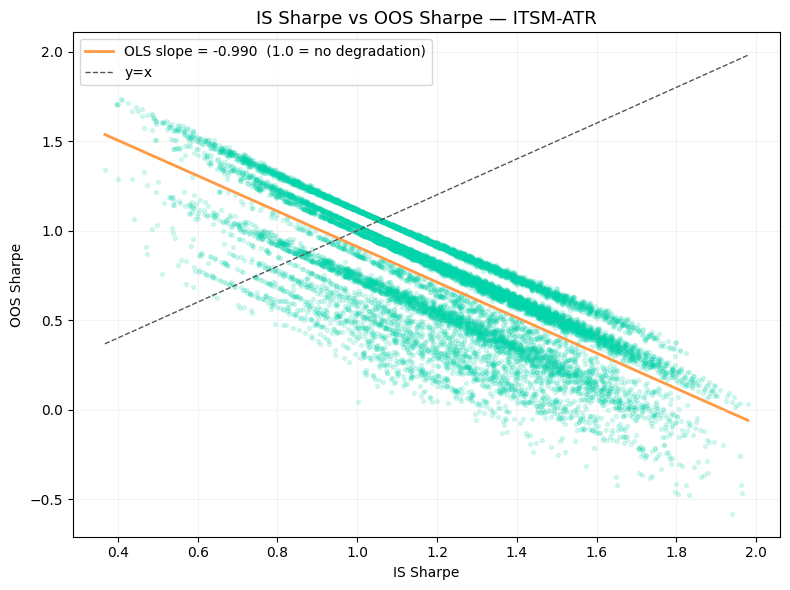

In [11]:
slope, intercept = np.polyfit(is_sharpes, oos_sharpes, 1)
xs = np.linspace(is_sharpes.min(), is_sharpes.max(), 100)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(is_sharpes, oos_sharpes, alpha=0.15, s=8, color='#00d4aa')
ax.plot(xs, slope*xs+intercept, color='#ff9944', lw=2,
        label=f'OLS slope = {slope:.3f}  (1.0 = no degradation)')
ax.plot(xs, xs, color='#555555', lw=1, linestyle='--', label='y=x')
ax.axhline(0, color='white', lw=0.6, linestyle='--', alpha=0.4)
ax.set_title('IS Sharpe vs OOS Sharpe — ITSM-ATR', fontsize=13)
ax.set_xlabel('IS Sharpe'); ax.set_ylabel('OOS Sharpe')
ax.legend(); ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

## Chart 3 — PBO Decomposed by Parameter Dimension

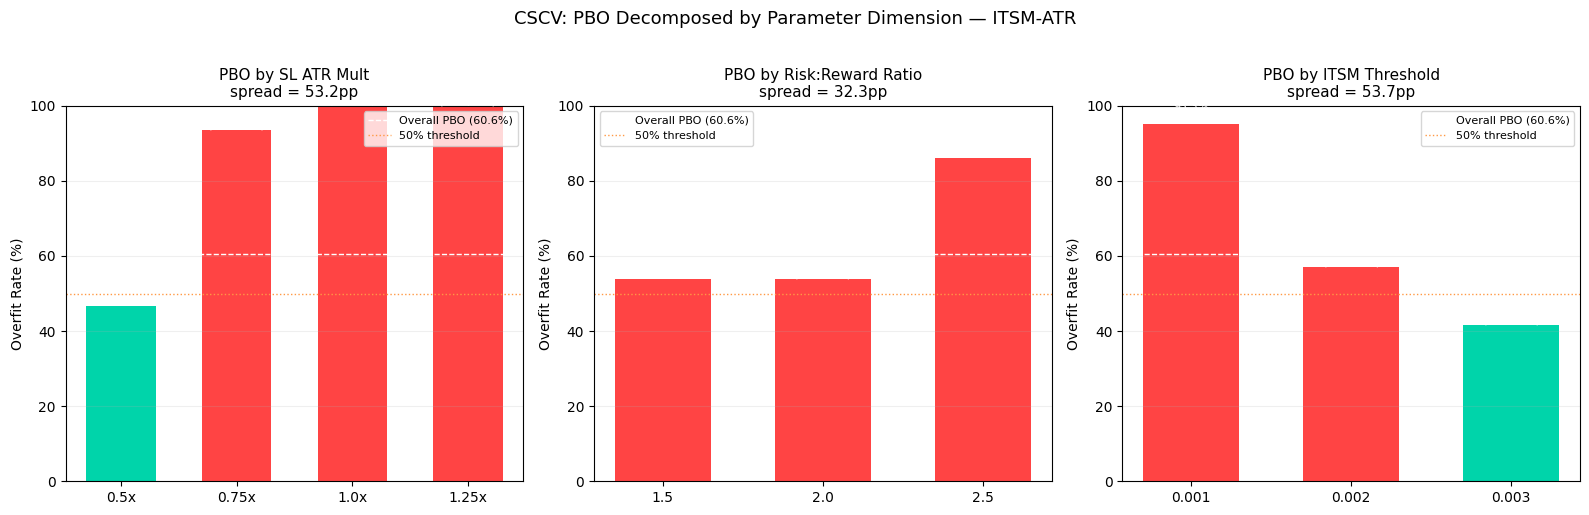

PBO spread by dimension:
  Threshold           : 53.7 pp
  SL ATR mult         : 53.2 pp
  RR ratio            : 32.3 pp

Comparison: ORB v4 SL/TP spread was 83.7pp, ORB+ITSM v5 was 70.4pp


In [12]:
sel_sl  = np.array([variants[v]['sl_atr_mult']    for v in selected_variants])
sel_rr  = np.array([round(variants[v]['tp_atr_mult'] / variants[v]['sl_atr_mult'], 2)
                    for v in selected_variants])
sel_thr = np.array([variants[v]['itsm_threshold']  for v in selected_variants])
overfit = logits < 0

def pbo_by_dim(dim_vals, unique_vals):
    pbos, counts = [], []
    for u in unique_vals:
        mask = np.isclose(dim_vals, u)
        pbos.append(overfit[mask].mean() * 100 if mask.sum() > 0 else float('nan'))
        counts.append(mask.sum())
    return pbos, counts

sl_pbos,  sl_counts  = pbo_by_dim(sel_sl,  SL_MULTS)
rr_pbos,  rr_counts  = pbo_by_dim(sel_rr,  RR_RATIOS)
thr_pbos, thr_counts = pbo_by_dim(sel_thr, THRESHOLDS)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, labels, pbos, counts, title in [
    (axes[0], [f'{v}x' for v in SL_MULTS],          sl_pbos,  sl_counts,  'SL ATR Mult'),
    (axes[1], [str(v) for v in RR_RATIOS],           rr_pbos,  rr_counts,  'Risk:Reward Ratio'),
    (axes[2], [f'{v:.3f}' for v in THRESHOLDS],      thr_pbos, thr_counts, 'ITSM Threshold'),
]:
    valid_pbos  = [p for p in pbos if p == p]
    valid_labels = [l for l, p in zip(labels, pbos) if p == p]
    valid_counts = [c for c, p in zip(counts, pbos) if p == p]
    bar_colors   = ['#ff4444' if p > 50 else '#00d4aa' for p in valid_pbos]
    bars = ax.bar(valid_labels, valid_pbos, color=bar_colors, width=0.6)
    ax.axhline(pbo*100, color='white', lw=1, linestyle='--',
               label=f'Overall PBO ({pbo*100:.1f}%)')
    ax.axhline(50, color='#ff9944', lw=1, linestyle=':', label='50% threshold')
    for bar, p, c in zip(bars, valid_pbos, valid_counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{p:.1f}%\n(n={c:,})', ha='center', fontsize=8, color='white')
    spread = max(valid_pbos) - min(valid_pbos) if valid_pbos else 0
    ax.set_title(f'PBO by {title}\nspread = {spread:.1f}pp', fontsize=11)
    ax.set_ylabel('Overfit Rate (%)')
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.2)

plt.suptitle('CSCV: PBO Decomposed by Parameter Dimension — ITSM-ATR', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

spreads = {
    'SL ATR mult': max(sl_pbos) - min([p for p in sl_pbos if p==p]),
    'RR ratio':    max(rr_pbos) - min([p for p in rr_pbos if p==p]),
    'Threshold':   max(thr_pbos)- min([p for p in thr_pbos if p==p]),
}
print('PBO spread by dimension:')
for k, v in sorted(spreads.items(), key=lambda x: -x[1]):
    print(f'  {k:20s}: {v:.1f} pp')
print(f'\nComparison: ORB v4 SL/TP spread was 83.7pp, ORB+ITSM v5 was 70.4pp')

---
## Section 4 — Summary & Verdict

In [13]:
from IPython.display import display, Markdown

best_idx     = int(np.argmax(full_sharpes))
best_v       = variants[best_idx]
baseline_idx = next(
    i for i, v in enumerate(variants)
    if abs(v['sl_atr_mult'] - 0.5) < 0.01
    and abs(v['tp_atr_mult'] - 1.0) < 0.01
    and abs(v['itsm_threshold'] - 0.002) < 0.0001
)
baseline_rank = int(np.sum(full_sharpes <= full_sharpes[baseline_idx]))

sharpe_deg = (1 - np.median(oos_sharpes) / np.median(is_sharpes)) * 100
selection_counts = np.bincount(selected_variants, minlength=N)

oos_success_rate = np.full(N, np.nan)
for v_idx in range(N):
    mask = selected_variants == v_idx
    if mask.sum() >= 10:
        oos_success_rate[v_idx] = (logits[mask] >= 0).mean() * 100

display(Markdown('### CSCV Setup'))
display(pd.DataFrame([
    ('N strategy variants',  N,                          'ATR-scaled SL/TP x threshold grid'),
    ('S splits',             S,                          'equal time slices'),
    ('IS/OOS combinations',  f'{results["n_combos"]:,}', 'C(16,8)'),
    ('T trading days',       T,                          'rows in P&L matrix'),
], columns=['Metric','Value','Description']))

display(Markdown('### Overfitting Diagnostics'))
display(pd.DataFrame([
    ('PBO',                 f'{pbo*100:.1f}%',                       pbo_verdict(pbo)),
    ('vs ORB-only (v4)',    '47.7%  ->  ?',                          'compare PBO reduction'),
    ('vs ORB+ITSM (v5)',    '65.9%  ->  ?',                          'compare PBO reduction'),
    ('Median IS Sharpe',    f'{np.median(is_sharpes):.3f}',           'training-half Sharpe'),
    ('Median OOS Sharpe',   f'{np.median(oos_sharpes):.3f}',          'unseen-half Sharpe'),
    ('Sharpe degradation',  f'{sharpe_deg:.0f}%',                     'IS to OOS drop'),
    ('OLS slope',           f'{slope:.3f}',                           '1.0 = robust, 0 = noise'),
    ('Prob(loss OOS)',       f'{prob_loss*100:.1f}%',                  'fraction with OOS Sharpe < 0'),
], columns=['Metric','Value','Notes']))

display(Markdown('### Best Variant & Baseline'))
display(pd.DataFrame([
    ('Best (CSCV full)',
     f'SL={best_v["sl_atr_mult"]}xATR  TP={best_v["tp_atr_mult"]}xATR  thr={best_v["itsm_threshold"]}',
     f'{full_sharpes[best_idx]:.3f}',
     f'{best_idx+1}/{N}'),
    ('Baseline (SL=0.5,TP=1.0,thr=0.002)',
     'SL=0.5xATR  TP=1.0xATR  thr=0.002',
     f'{full_sharpes[baseline_idx]:.3f}',
     f'{baseline_rank}/{N}'),
], columns=['Variant','Parameters','Full-Dataset Sharpe','Rank']))

display(Markdown('### Final Verdict'))
sharpe_val = get_float(m_base['Sharpe'])
mdd_val    = get_float(m_base['Max Drawdown'])
baseline_oos = oos_success_rate[baseline_idx] if not np.isnan(oos_success_rate[baseline_idx]) else None
display(pd.DataFrame([
    ('Sharpe target (>1.0)',       'PASS' if sharpe_val > 1.0 else 'FAIL',
     f'Baseline Sharpe = {sharpe_val:.3f}'),
    ('Max DD target (<10%)',       'PASS' if mdd_val < 10.0 else 'FAIL',
     f'Baseline Max DD = {mdd_val:.1f}%'),
    ('Beats S&P 500 Sharpe',       'PASS' if sharpe_val > SP500_SHARPE else 'FAIL',
     f'{sharpe_val:.2f} vs S&P 500 {SP500_SHARPE}'),
    ('Edge exists (OOS)',          'YES' if prob_loss < 0.10 else 'UNCERTAIN',
     f'Prob(loss OOS) = {prob_loss*100:.1f}%'),
    ('PBO level',                  pbo_verdict(pbo),
     f'{pbo*100:.1f}%  (ORB had 47.7%, ORB+ITSM had 65.9%)'),
    ('Forward Sharpe estimate',    f'~{np.median(oos_sharpes):.2f}',
     'OOS median — realistic expectation'),
    ('Baseline OOS success rate',  f'{baseline_oos:.1f}%' if baseline_oos else 'N/A',
     '% of times selected -> logit >= 0'),
], columns=['Question','Answer','Detail']))

### CSCV Setup

,Metric,Value,Description
0,N strategy variants,36,ATR-scaled SL/TP x threshold grid
1,S splits,16,equal time slices
2,IS/OOS combinations,"12,870","C(16,8)"
3,T trading days,2164,rows in P&L matrix


### Overfitting Diagnostics

,Metric,Value,Notes
0,PBO,60.6%,HIGH OVERFITTING RISK (PBO >= 50%)
1,vs ORB-only (v4),47.7% -> ?,compare PBO reduction
2,vs ORB+ITSM (v5),65.9% -> ?,compare PBO reduction
3,Median IS Sharpe,1.220,training-half Sharpe
4,Median OOS Sharpe,0.703,unseen-half Sharpe
5,Sharpe degradation,42%,IS to OOS drop
6,OLS slope,-0.990,"1.0 = robust, 0 = noise"
7,Prob(loss OOS),2.1%,fraction with OOS Sharpe < 0


### Best Variant & Baseline

,Variant,Parameters,Full-Dataset Sharpe,Rank
0,Best (CSCV full),SL=0.5xATR TP=0.75xATR thr=0.003,1.044,3/36
1,"Baseline (SL=0.5,TP=1.0,thr=0.002)",SL=0.5xATR TP=1.0xATR thr=0.002,0.984,34/36


### Final Verdict

,Question,Answer,Detail
0,Sharpe target (>1.0),PASS,Baseline Sharpe = 1.151
1,Max DD target (<10%),PASS,Baseline Max DD = 9.5%
2,Beats S&P 500 Sharpe,PASS,1.15 vs S&P 500 0.6
3,Edge exists (OOS),YES,Prob(loss OOS) = 2.1%
4,PBO level,HIGH OVERFITTING RISK (PBO >= 50%),"60.6% (ORB had 47.7%, ORB+ITSM had 65.9%)"
5,Forward Sharpe estimate,~0.70,OOS median — realistic expectation
6,Baseline OOS success rate,75.2%,% of times selected -> logit >= 0
